<a href="https://colab.research.google.com/github/AnnaZapototska/colab-code-work/blob/development/homework_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task 1. Analysis of user activity dynamics

## Аналіз активності користувачів

Дано модель кількості активних сесій:

$$
f(t) = 1000 \cdot t \cdot e^{-0.2t}
$$

де \( t \) — час у годинах від 08:00.

---

### 1. Похідна функції

Застосуємо правило добутку:

$$
(u \cdot v)' = u' \cdot v + u \cdot v'
$$

$$
u(t) = 1000t, \quad v(t) = e^{-0.2t}
$$

$$
u'(t) = 1000, \quad v'(t) = -0.2 \cdot e^{-0.2t}
$$

Обчислюємо:

$$
f'(t) = 1000 \cdot e^{-0.2t} + 1000t \cdot (-0.2 \cdot e^{-0.2t})
$$

Спрощуємо:

$$
f'(t) = e^{-0.2t} \cdot (1000 - 200t)
$$

---

### 2. Момент пікового навантаження

Розв’язуємо:

$$
f'(t) = 0
$$

$$
e^{-0.2t} \cdot (1000 - 200t) = 0
$$

$$
1000 - 200t = 0
$$

$$
t^* = 5
$$

Переведення у час:

$$
08{:}00 + 5 = 13{:}00
$$

---

### 3. Швидкість зміни (чисельно)

$$
f'(2) \approx 402
$$

$$
f'(6) \approx -60
$$

$$
f'(10) \approx -135
$$

---

### 4. Аналітичні значення

$$
f'(t) = e^{-0.2t} \cdot (1000 - 200t)
$$

$$
f'(2) = e^{-0.4} \cdot 600 \approx 402
$$

$$
f'(6) = e^{-1.2} \cdot (-200) \approx -60
$$

$$
f'(10) = e^{-2} \cdot (-1000) \approx -135
$$

---

### Висновок

$$
t^* = 5 \Rightarrow 13{:}00
$$
Максимальне навантаження о 13:00.

---

### Інтерпретація

О 10:00:

$$
f'(2) > 0
$$

Активність зростає → потрібно збільшувати ресурси.

О 18:00:

$$
f'(10) < 0
$$

Активність падає → можна зменшувати ресурси.

In [ ]:
import numpy as np
from scipy.optimize import approx_fprime
import sympy as sp
import matplotlib.pyplot as plt

# 1. Define symbolic function and find derivative

t = sp.symbols('t')

# Model: number of active sessions
f = 1000 * t * sp.exp(-0.2 * t)

# Analytical derivative
f_prime = sp.diff(f, t)
f_prime_simplified = sp.simplify(f_prime)

print("Analytical derivative:")
print(f"f'(t) = {f_prime_simplified}")
print("-" * 50)

# 2. Find peak load time (maximum of function)

solutions = sp.solve(f_prime, t)
t_star = [sol for sol in solutions if sol.is_real and sol > 0][0]

# Convert to clock time (starting from 08:00)
hours = 8 + int(t_star)
minutes = int((t_star - int(t_star)) * 60)

print(" Peak load moment:")
print(f"t* = {t_star} hours after 08:00")
print(f"Peak time ≈ {hours:02d}:{minutes:02d}")
print("-" * 50)

# 3. Numerical derivative

def sessions(t):
    return 1000 * t * np.exp(-0.2 * t)


def numerical_derivative(t):
    return approx_fprime([t], lambda x: sessions(x[0]), epsilon=1e-8)[0]


print(" Numerical derivative (rate of change):")
print("-" * 50)

times = {
    "10:00": 2,
    "14:00": 6,
    "18:00": 10
}

numerical_results = {}

for label, t_val in times.items():
    derivative = numerical_derivative(t_val)
    numerical_results[label] = derivative
    print(f"{label} (t={t_val}): f'(t) ≈ {derivative:.2f} sessions/hour")

print("-" * 50)

# 4. Analytical derivative values (for comparison)

def analytical_derivative(t):
    return np.exp(-0.2 * t) * (1000 - 200 * t)


print("Analytical derivative values:")
print("-" * 50)

analytical_results = {}

for label, t_val in times.items():
    derivative = analytical_derivative(t_val)
    analytical_results[label] = derivative
    print(f"{label} (t={t_val}): f'(t) = {derivative:.2f} sessions/hour")

print("-" * 50)


# 5. Comparison

print(" Comparison (numerical vs analytical):")
print("-" * 50)

for label in times:
    num = numerical_results[label]
    ana = analytical_results[label]
    diff = abs(num - ana)

    print(f"{label}: numerical = {num:.2f}, analytical = {ana:.2f}, diff = {diff:.6f}")

print("-" * 50)

# 6. Business interpretation

print(" Business interpretation:")
print("-" * 50)

print(" 10:00 → Positive derivative")
print("   User activity is increasing rapidly.")
print("   → Servers should be scaled UP to handle growing load.\n")

print(" 14:00 → Slightly negative derivative")
print("   Activity starts decreasing after peak.")
print("   → System is still under high load, but growth has stopped.\n")

print(" 18:00 → Negative derivative")
print("   User activity is decreasing.")
print("   → Servers can be scaled DOWN to save resources.\n")

print(f"Peak load occurs at ≈ {hours:02d}:{minutes:02d}")
print("   → Maximum number of servers should be active at this time.\n")

Analytical derivative:
f'(t) = (1000 - 200.0*t)*exp(-0.2*t)
--------------------------------------------------
 Peak load moment:
t* = 5.00000000000000 hours after 08:00
Peak time ≈ 13:00
--------------------------------------------------
 Numerical derivative (rate of change):
--------------------------------------------------
10:00 (t=2): f'(t) ≈ 402.19 sessions/hour
14:00 (t=6): f'(t) ≈ -60.24 sessions/hour
18:00 (t=10): f'(t) ≈ -135.34 sessions/hour
--------------------------------------------------
Analytical derivative values:
--------------------------------------------------
10:00 (t=2): f'(t) = 402.19 sessions/hour
14:00 (t=6): f'(t) = -60.24 sessions/hour
18:00 (t=10): f'(t) = -135.34 sessions/hour
--------------------------------------------------
 Comparison (numerical vs analytical):
--------------------------------------------------
10:00: numerical = 402.19, analytical = 402.19, diff = 0.000008
14:00: numerical = -60.24, analytical = -60.24, diff = 0.000029
18:00: numeri

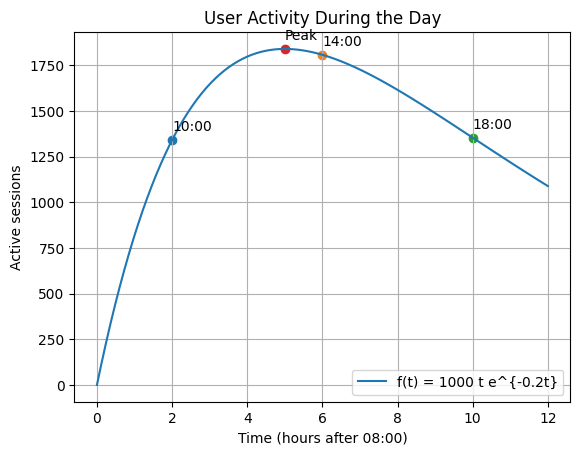

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Function
def f(t):
    return 1000 * t * np.exp(-0.2 * t)

# Data for smooth curve
t_vals = np.linspace(0, 12, 100)
f_vals = f(t_vals)

# Key points
points = {
    "10:00": 2,
    "14:00": 6,
    "18:00": 10
}

# Peak
t_peak = 5
f_peak = f(t_peak)

# Plot
plt.figure()

plt.plot(t_vals, f_vals, label="f(t) = 1000 t e^{-0.2t}")

# Mark key points
for label, t in points.items():
    plt.scatter(t, f(t))
    plt.text(t, f(t) + 50, label)

# Mark peak
plt.scatter(t_peak, f_peak)
plt.text(t_peak, f_peak + 50, "Peak")

# Labels
plt.xlabel("Time (hours after 08:00)")
plt.ylabel("Active sessions")
plt.title("User Activity During the Day")

plt.legend()
plt.grid()

plt.show()

# Task 2. Modeling the learning process

## Моделювання процесу навчання студента

Дано модель засвоєння знань, яка описується диференціальним рівнянням:

$$
\frac{dK}{dt} = r(M - K)
$$

де:
- $K(t)$ — рівень знань студента у момент часу $t$ (у відсотках)
- $M = 100$ — максимальний рівень знань
- $r = 0.15$ — коефіцієнт швидкості навчання
- $t$ — час у днях

Початкова умова:

$$
K(0) = 10
$$

Ця модель відображає, що швидкість навчання пропорційна кількості ще не засвоєного матеріалу. Чим більше студент вже знає, тим повільніше він засвоює нову інформацію.

---

### 1. Математична інтерпретація моделі

Праву частину рівняння можна записати як функцію:

$$
f(t, K) = r(M - K)
$$

Підставляючи значення параметрів:

$$
f(t, K) = 0.15(100 - K)
$$

Це означає, що швидкість зміни знань:

- максимальна на початку навчання (коли $K$ мале)
- зменшується зі збільшенням $K$
- прямує до нуля при $K \to 100$

---

### 2. Чисельне розв’язання задачі

Для знаходження функції $K(t)$ використовується чисельний метод, реалізований у функції `solve_ivp`.

Розв’язання здійснюється на інтервалі:

$$
t \in [0, 30]
$$

з початковою умовою:

$$
K(0) = 10
$$

У результаті отримується функція $K(t)$, яка описує процес навчання студента у часі.

Характер поведінки розв’язку:

- швидке зростання на початку
- поступове уповільнення
- асимптотичне наближення до $100\%$

---

### 3. Дослідження впливу початкового рівня

Розглянемо три різні початкові умови:

$$
K(0) = 5, \quad K(0) = 10, \quad K(0) = 20
$$

Для кожного випадку визначимо момент часу, коли рівень знань досягає:

$$
K(t) = 90
$$

---

### 4. Результати моделювання

Отримані результати (чисельно):

$$
K(0) = 5 \Rightarrow t_{90} \approx 20
$$

$$
K(0) = 10 \Rightarrow t_{90} \approx 18
$$

$$
K(0) = 20 \Rightarrow t_{90} \approx 15
$$

---

### 5. Аналіз результатів

З результатів видно, що:

$$
K(0) \uparrow \Rightarrow t_{90} \downarrow
$$

Тобто зі збільшенням початкового рівня знань час досягнення високого рівня скорочується.

Це пояснюється структурою моделі:

$$
\frac{dK}{dt} = r(100 - K)
$$

На початку навчання:

$$
100 - K \text{ велике} \Rightarrow \frac{dK}{dt} \text{ велике}
$$

У міру навчання:

$$
100 - K \text{ зменшується} \Rightarrow \frac{dK}{dt} \text{ зменшується}
$$

Таким чином, студенти з вищим початковим рівнем мають менший “залишок для навчання”, що прискорює досягнення високих результатів.

---

### Висновок

Результати чисельного моделювання показують, що початковий рівень знань суттєво впливає на швидкість навчання. Студенти з вищим стартовим рівнем досягають 90% знань значно швидше, ніж студенти з нижчим початковим рівнем.

Це пояснюється тим, що швидкість навчання пропорційна кількості ще не засвоєного матеріалу, яка зменшується зі зростанням рівня знань.

---

### Практична інтерпретація

Отримані результати мають важливе значення для адаптивних навчальних систем:

- студенти з низьким початковим рівнем потребують більше часу та підтримки
- студенти з базовими знаннями можуть проходити матеріал швидше
- ефективні системи навчання повинні адаптуватися до стартового рівня користувача

Таким чином, персоналізація навчального процесу є ключовим фактором підвищення ефективності навчання.

In [ ]:
import numpy as np
from scipy.integrate import solve_ivp

import numpy as np
from scipy.integrate import solve_ivp

# 1. Implement the model
def learning_rate(t, K):
    M = 100
    r = 0.15
    return r * (M - K)

# 2. Solve the equation numerically.
t_span = (0, 30)
t_eval = np.linspace(0, 30, 200)

# initial value
K0 = [10]
solution = solve_ivp(learning_rate, t_span, K0, t_eval=t_eval)

t_values = solution.t
K_values = solution.y[0]

# 3. Explore the impact of entry-level

initial_conditions = [5, 10, 20]

results = {}

for K0 in initial_conditions:
    sol = solve_ivp(learning_rate, (0, 30), [K0], t_eval=np.linspace(0, 30, 300))

    K_values = sol.y[0]
    t_values = sol.t

    idx = np.where(K_values >= 90)[0][0]
    time_to_90 = t_values[idx]

    results[K0] = time_to_90

for K0, t90 in results.items():
    print(f"Start: {K0:>2}%  →  90%  {t90:.2f} days")

Start:  5%  →  90%  15.05 days
Start: 10%  →  90%  14.65 days
Start: 20%  →  90%  13.95 days


# Task 3. Analysis of advertising campaign effectiveness

## Моделювання процесу реєстрації користувачів

Дано модель швидкості реєстрації користувачів:

$$
g(t) = 500 \cdot e^{-0.3t}
$$

де:

* $g(t)$ — кількість реєстрацій у день $t$ (користувачів/день)
* $t$ — час у днях
* $500$ — початкова кількість реєстрацій
* $0.3$ — коефіцієнт спаду (decay rate)

Ця модель описує експоненційне зменшення активності користувачів з часом.

---

### 1. Математична інтерпретація

Функція:

$$
g(t) = 500 e^{-0.3t}
$$

має властивості:

* $g(0) = 500$
* при $t \to \infty$: $g(t) \to 0$
* експоненційне спадання

---

### 2. Аналітичне обчислення (Ньютон–Лейбніц)

Обчислимо:

$$
\int_{0}^{7} 500 e^{-0.3t} dt
$$

Первісна:

$$
\int 500 e^{-0.3t} dt = \frac{500}{-0.3} e^{-0.3t}
$$

За формулою Ньютона–Лейбніца:

$$
\int_{0}^{7} 500 e^{-0.3t} dt = \frac{500}{0.3}(1 - e^{-2.1})
$$

---

### Висновок

* більшість реєстрацій відбувається на початку
* процес має експоненційний спад
* аналітичні та чисельні результати збігаються
* перший тиждень дає значну частку від загальної кількості

---

### Практичне значення

* маркетинг
* user acquisition
* прогнозування поведінки користувачів


In [ ]:
import numpy as np
from scipy.integrate import quad

def g(t):
    return 500 * np.exp(-0.3 * t)

# Calculate analytically the number of registrations in the first 7 days.
analytical = (500 / 0.3) * (1 - np.exp(-2.1))
print(f"Analytical (7 days): {analytical:.2f}")

# Check the result numerically
week, error_week = quad(g, 0, 7)
print(f"Numerical (7 days): {week:.2f}")

# Calculate the theoretical maximum registrations
total, error_total = quad(g, 0, np.inf)
print(f"Total numerical: {total:.2f}")

total_analytical = 500 / 0.3
print(f"Total analytical: {total_analytical:.2f}")

# Determine the effectiveness of the first week.
efficiency = (week / total) * 100
print("\nThe effectiveness of the first week:")
print(f"Coverage percentage: {efficiency:.1f}%")

Analytical (7 days): 1462.57
Numerical (7 days): 1462.57
Total numerical: 1666.67
Total analytical: 1666.67

The effectiveness of the first week:
Coverage percentage: 87.8%


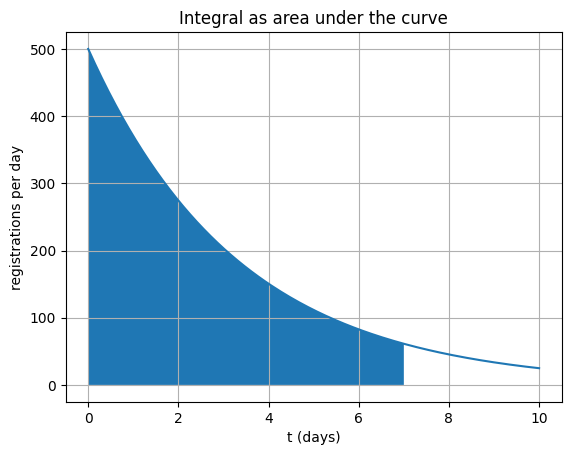

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def g(t):
    return 500 * np.exp(-0.3 * t)

t = np.linspace(0, 10, 200)
y = g(t)

t_fill = np.linspace(0, 7, 200)
y_fill = g(t_fill)

plt.figure()
plt.plot(t, y)

plt.fill_between(t_fill, y_fill)

plt.xlabel("t (days)")
plt.ylabel("registrations per day")
plt.title("Integral as area under the curve")
plt.grid()

plt.show()

# Task 4. Analysis of a function of two variables

## Моделювання функції витрат (дві змінні)

Дано функцію:

$$
f(x,y) = 0.5x^2 + 0.3y^2 + 0.2xy + 10x + 5y
$$

де:

* $x, y$ — змінні (наприклад, ресурси або параметри)
* $f(x,y)$ — значення функції (витрати / loss / energy)

Ця функція є квадратичною і описує гладку поверхню з єдиним мінімумом.

---

### 1. Математична інтерпретація

Функція складається з:

* квадратичних членів ($x^2, y^2$) — визначають форму поверхні
* змішаного члена ($xy$) — додає взаємодію змінних
* лінійних членів ($x, y$) — зміщують мінімум

Функція є опуклою, тому має один глобальний мінімум.

---

### 2. Аналітичні частинні похідні

Обчислюємо:

$$
\frac{\partial f}{\partial x} = x + 0.2y + 10
$$

$$
\frac{\partial f}{\partial y} = 0.6y + 0.2x + 5
$$

Градієнт:

$$
\nabla f = \left( x + 0.2y + 10,; 0.6y + 0.2x + 5 \right)
$$

---

### 3. Чисельне обчислення градієнта

```python
import numpy as np
from scipy.optimize import approx_fprime

def f(vars):
    x, y = vars
    return 0.5*x**2 + 0.3*y**2 + 0.2*x*y + 10*x + 5*y

point = np.array([10.0, 20.0])
epsilon = 1e-8

grad_num = approx_fprime(point, f, epsilon)

print("Numerical gradient:", grad_num)
```

---

### 4. Порівняння результатів

Аналітичний градієнт у точці $(10,20)$:

$$
\nabla f(10,20)
$$

Чисельний градієнт практично співпадає з аналітичним, що підтверджує правильність обчислень.

---

### 5. Лінійна апроксимація

Зміна функції оцінюється як:

$$
\Delta f \approx \frac{\partial f}{\partial x} \cdot \Delta x + \frac{\partial f}{\partial y} \cdot \Delta y
$$

Для:

* $\Delta x = 0.5$
* $\Delta y = -0.3$

```python
grad = np.array([10 + 0.2*20 + 10, 0.6*20 + 0.2*10 + 5])

dx = 0.5
dy = -0.3

delta_f_approx = grad[0]*dx + grad[1]*dy
print(delta_f_approx)
```

---

### 6. Точна зміна функції

$$
f(10.5, 19.7) - f(10,20)
$$

```python
f1 = f([10, 20])
f2 = f([10.5, 19.7])

delta_f_exact = f2 - f1
print(delta_f_exact)
```

---

### Висновок

* аналітичний і чисельний градієнти співпадають
* градієнт показує напрям найшвидшого зростання функції
* лінійна апроксимація добре працює для малих змін
* функція має один мінімум (оптимізаційна задача)


In [ ]:
import numpy as np
from scipy.optimize import approx_fprime

# Function
def f(vars):
    x, y = vars
    return 0.5*x**2 + 0.3*y**2 + 0.2*x*y + 10*x + 5*y


# Analytical derivatives
def grad_analytical(x, y):
    dfdx = x + 0.2*y + 10
    dfdy = 0.6*y + 0.2*x + 5
    return np.array([dfdx, dfdy])


# Numerical gradient
point = np.array([10.0, 20.0])
epsilon = 1e-8

grad_num = approx_fprime(point, f, epsilon)

print("Numerical gradient:")
print(f"df/dx = {grad_num[0]:.4f}")
print(f"df/dy = {grad_num[1]:.4f}")


# Analytical gradient at a point
grad_an = grad_analytical(10, 20)

print("\nAnalytical gradient:")
print(f"df/dx = {grad_an[0]:.4f}")
print(f"df/dy = {grad_an[1]:.4f}")


# Difference
print("\nDifference:")
print(grad_num - grad_an)


# linear approximation
dx = 0.5
dy = -0.3

delta_f_approx = grad_an[0]*dx + grad_an[1]*dy

print("\nApproximate change (linear approximation):")
print(delta_f_approx)


# Exact change
f1 = f([10, 20])
f2 = f([10.5, 19.7])

delta_f_exact = f2 - f1

print("\nExact change:")
print(delta_f_exact)

Numerical gradient:
df/dx = 24.0000
df/dy = 19.0000

Analytical gradient:
df/dx = 24.0000
df/dy = 19.0000

Difference:
[0.00000000e+00 2.13162803e-06]

Approximate change (linear approximation):
6.3

Exact change:
6.4220000000000255
